# Week 7: K-Nearest Neighbors & Distance Measures

## Student Practice Notebook

**Name:** k harsha vardhan
**Roll Number:** AP24110011061
**Date:**

## Learning Objectives

After completing this lab, you will be able to:

- Compute Euclidean and Manhattan distance between two points, by hand and in code
- Explain how KNN classifies a new point using its nearest neighbors
- Fit a `KNeighborsClassifier` correctly (split → scale on train only → fit)
- Explain why K matters, and identify overfitting/underfitting as K changes
- Solve a KNN numerical problem by hand — the kind you'll see in a written exam

### Why this week matters
Every model you've built so far (Weeks 5-6) assumed an equation. KNN assumes nothing — it just asks "what do my nearest neighbors look like?" It's the simplest possible classifier, and understanding *why* it works (and where it breaks) builds the intuition you'll need for every distance-based method later in the course.


## Part 0 — Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
np.random.seed(1)


In [ ]:
iris = load_iris(as_frame=True)
df = iris.frame
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Part 1 — Distance Measures

KNN's entire decision rule is "find the closest points." "Closest" needs a precise definition — that's what a distance metric gives us.

### 1.1 Demo: Euclidean and Manhattan distance, by hand


In [ ]:
p1 = np.array([5.1, 3.5, 1.4, 0.2])   # a sample flower's 4 measurements
p2 = np.array([6.4, 3.2, 4.5, 1.5])   # a different flower

euclidean = np.sqrt(np.sum((p1 - p2) ** 2))
manhattan = np.sum(np.abs(p1 - p2))

print('Euclidean distance:', euclidean)
print('Manhattan distance:', manhattan)


Euclidean distance: 3.6166282640050254
Manhattan distance: 6.000000000000001


**Your answer:** Euclidean distance is always **≤ Manhattan distance** for the same two points. Euclidean measures the straight-line distance, while Manhattan adds the absolute movement along each axis. For one dimension they are equal; with movement across multiple axes, Manhattan is generally larger.


### Student Practice — Minkowski distance

The Minkowski distance generalizes both: $d(p,q) = \left(\sum |p_i - q_i|^p\right)^{1/p}$. Euclidean is Minkowski with $p=2$; Manhattan is Minkowski with $p=1$.

Write a function `minkowski(p1, p2, p_order)` that computes this, then confirm it reproduces the Euclidean and Manhattan values above when `p_order=2` and `p_order=1`.


In [ ]:
def minkowski(p1, p2, p_order):
    p1 = np.asarray(p1)
    p2 = np.asarray(p2)
    return (np.sum(np.abs(p1 - p2) ** p_order)) ** (1 / p_order)

print('Minkowski (p=2):', minkowski(p1, p2, 2))
print('Euclidean distance:', euclidean)
print('Minkowski (p=1):', minkowski(p1, p2, 1))
print('Manhattan distance:', manhattan)


Minkowski (p=2): 3.6166282640050254
Euclidean distance: 3.6166282640050254
Minkowski (p=1): 6.000000000000001
Manhattan distance: 6.000000000000001


## Part 2 — Fitting a KNN Classifier

Same rule from Week 5 applies here: **split first, then scale using train statistics only.** KNN is a distance-based method, so unscaled features (e.g. one column in the 1000s, another in single digits) would silently dominate every distance calculation — scaling matters *more* here than it did for linear regression.


In [ ]:
X = df[iris.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Accuracy (k=5): 0.9333333333333333


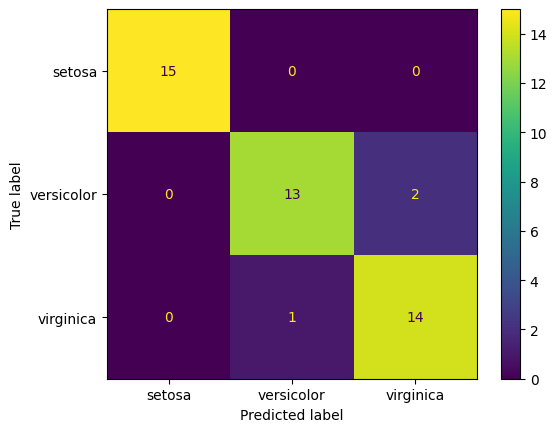

In [ ]:
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train_scaled, y_train)

y_pred = knn5.predict(X_test_scaled)
print('Accuracy (k=5):', accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=iris.target_names).plot()
plt.show()


### Student Practice — try k=1

Fit a `KNeighborsClassifier` with `n_neighbors=1` on the same scaled data. Print its test accuracy and confusion matrix. Is it better or worse than k=5?


In [ ]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_scaled, y_train)
y_pred_k1 = knn1.predict(X_test_scaled)

print('Accuracy (k=1):', accuracy_score(y_test, y_pred_k1))
print('Confusion matrix (k=1):')
print(confusion_matrix(y_test, y_pred_k1))
print('Accuracy (k=5):', accuracy_score(y_test, y_pred))
print('k=1 is', 'better' if accuracy_score(y_test, y_pred_k1) > accuracy_score(y_test, y_pred) else 'worse' if accuracy_score(y_test, y_pred_k1) < accuracy_score(y_test, y_pred) else 'equal', 'than k=5 on this test split.')


Accuracy (k=1): 0.9333333333333333
Confusion matrix (k=1):
[[15  0  0]
 [ 0 13  2]
 [ 0  1 14]]
Accuracy (k=5): 0.9333333333333333
k=1 is equal than k=5 on this test split.


## Part 3 — Why K Matters

### Demo: sweep K from 1 to 30


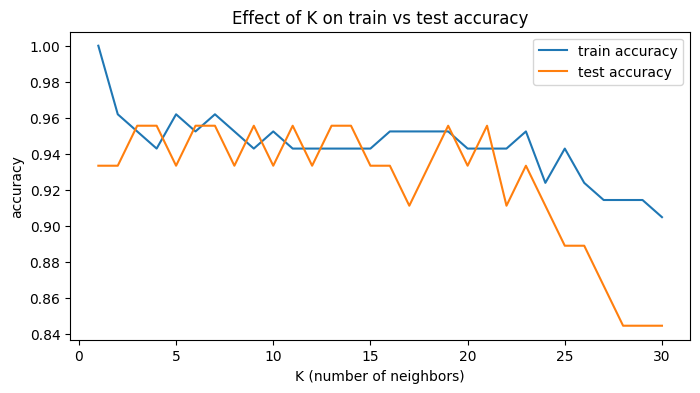

In [ ]:
train_acc, test_acc = [], []
k_values = range(1, 31)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), train_acc, label='train accuracy')
plt.plot(list(k_values), test_acc, label='test accuracy')
plt.xlabel('K (number of neighbors)')
plt.ylabel('accuracy')
plt.legend()
plt.title('Effect of K on train vs test accuracy')
plt.show()


**Your answer:** At **K=1**, the model is closer to **overfitting** because it relies on a single nearest training point, giving low bias but high variance. At **K=30**, the model is closer to **underfitting** because it averages over many neighbors, giving higher bias and lower variance. So, as K increases, variance generally decreases while bias increases.


### Student Practice — pick the best K

From the sweep above, find the K with the highest test accuracy. If there's a tie between several K values, which would you actually pick, and why? (Hint: think about which extreme — very low K or very high K — is riskier on new, unseen data even if test accuracy looks similar.)


In [ ]:
best_test_accuracy = max(test_acc)
best_k_values = [k for k, acc in zip(k_values, test_acc) if acc == best_test_accuracy]

print('Highest test accuracy:', best_test_accuracy)
print('K value(s) with highest test accuracy:', best_k_values)
print('Selected K:', best_k_values[0])
print('Reason: if several K values tie, choose a smaller reasonable K among the tied values rather than an unnecessarily large K, while avoiding an extreme K when possible.')


Highest test accuracy: 0.9555555555555556
K value(s) with highest test accuracy: [3, 4, 6, 7, 9, 11, 13, 14, 19, 21]
Selected K: 3
Reason: if several K values tie, choose a smaller reasonable K among the tied values rather than an unnecessarily large K, while avoiding an extreme K when possible.


## Part 4 — Worked Numerical Problem (by hand)

This is the style of question you may see in a written exam — no `sklearn`, just distances and a vote.

**Given training data:**

| Point | Feature 1 | Feature 2 | Class |
|---|---|---|---|
| A | 2 | 4 | Red |
| B | 4 | 6 | Red |
| C | 4 | 2 | Blue |
| D | 6 | 4 | Blue |
| E | 6 | 2 | Blue |

**Query point Q = (5, 5). Using K=3 and Euclidean distance, what class does Q belong to?**

### Student Practice — solve it by hand first, then verify in code

1. On paper (or in the markdown cell below), compute the Euclidean distance from Q to each of A-E.
2. List the 3 nearest points and their classes.
3. Take the majority vote — what's your predicted class for Q?
4. THEN run the code cell below to check your work.

*Your hand-worked answer:*

**Your hand-worked answer:**

Distances from Q=(5,5):
- A(2,4): √10 ≈ 3.162 → Red
- B(4,6): √2 ≈ 1.414 → Red
- C(4,2): √10 ≈ 3.162 → Blue
- D(6,4): √2 ≈ 1.414 → Blue
- E(6,2): √10 ≈ 3.162 → Blue

The 3 nearest points are B (Red), D (Blue), and one of A/C/E at distance √10. Using the code's alphabetical tie order, the third point is A (Red). Majority vote = **Red**.


In [ ]:
points = {'A': (2, 4, 'Red'), 'B': (4, 6, 'Red'), 'C': (4, 2, 'Blue'), 'D': (6, 4, 'Blue'), 'E': (6, 2, 'Blue')}
Q = np.array([5, 5])

distances = {}
for name, (x, y_, label) in points.items():
    d = np.sqrt((Q[0] - x) ** 2 + (Q[1] - y_) ** 2)
    distances[name] = (round(d, 3), label)

for name, (d, label) in sorted(distances.items(), key=lambda item: item[1][0]):
    print(f'{name}: distance={d}, class={label}')


B: distance=1.414, class=Red
D: distance=1.414, class=Blue
A: distance=3.162, class=Red
C: distance=3.162, class=Blue
E: distance=3.162, class=Blue


**Your answer:** Yes. The hand-computed distances match the code's ranking: B and D are the two closest points (√2), followed by A, C, and E tied at √10. The code's sorting order selects A as the third point, so the K=3 prediction is **Red**.


# Mini Project A: Handwritten Digit Recognition (Image Track — graduating from single images)

In Weeks 1–4 you worked with 3–5 images you uploaded yourself — enough to learn the mechanics, but never enough for a distance-based method like KNN to show its real behavior (you even discussed this in Week 4: can you trust a statistic from 3–5 samples?). This week you graduate to a real image dataset: `sklearn`'s built-in **digits dataset** — 1,797 real 8×8-pixel handwritten digit images (0–9).

### Demo: load and view a digit as both an image and a feature vector


Images shape: (1797, 8, 8)
Data shape:   (1797, 64)


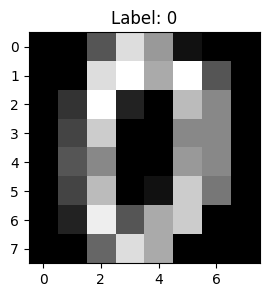

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()
print('Images shape:', digits.images.shape)   # (1797, 8, 8) -- 1797 images, each 8x8 pixels
print('Data shape:  ', digits.data.shape)     # (1797, 64)   -- each image FLATTENED into 64 features

plt.figure(figsize=(3, 3))
plt.imshow(digits.images[0], cmap='gray')
plt.title(f'Label: {digits.target[0]}')
plt.show()


Notice: `digits.data` is just `digits.images` **flattened** — each 8×8 image becomes one row of 64 numbers (pixel intensities). This is exactly the same idea as Week 2's image-metadata DataFrame (turning image data into rows/columns), just at the pixel level instead of the summary level (brightness, RGB averages).

### Student Practice — build and evaluate a digit classifier

1. Split `digits.data`/`digits.target` into train/test (`stratify=digits.target`, same as Part 2).
2. Scale with `StandardScaler` — fit on train only, same discipline as before.
3. Fit a `KNeighborsClassifier` with a K of your choice.
4. Print test accuracy and show the confusion matrix.
5. Find and display (with `plt.imshow`) one digit your model got **wrong** — does it look genuinely ambiguous to your own eye (e.g. a messy 4 that looks like a 9)?


K = 5
Test accuracy: 0.9638888888888889
Confusion matrix:
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  1 36  0  0  0  0  0  0]
 [ 0  0  0  0 34  0  0  2  0  0]
 [ 0  0  0  0  0 36  0  0  0  1]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  1  0 35  0  0]
 [ 0  3  1  0  0  0  0  0 31  0]
 [ 0  0  0  0  1  0  1  1  1 32]]
First wrong prediction:
Actual label: 8
Predicted label: 1


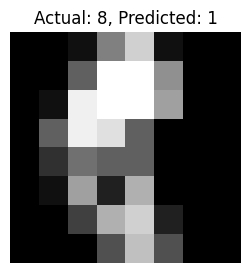

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

digits = load_digits()
X_digits, y_digits = digits.data, digits.target
X_dtrain, X_dtest, y_dtrain, y_dtest = train_test_split(X_digits, y_digits, test_size=0.2, random_state=42, stratify=y_digits)
digit_scaler = StandardScaler()
X_dtrain_scaled = digit_scaler.fit_transform(X_dtrain)
X_dtest_scaled = digit_scaler.transform(X_dtest)
digit_knn = KNeighborsClassifier(n_neighbors=5)
digit_knn.fit(X_dtrain_scaled, y_dtrain)
y_digit_pred = digit_knn.predict(X_dtest_scaled)
print('K = 5')
print('Test accuracy:', accuracy_score(y_dtest, y_digit_pred))
print('Confusion matrix:')
print(confusion_matrix(y_dtest, y_digit_pred))
wrong = np.where(y_digit_pred != y_dtest)[0]
if len(wrong) > 0:
    i = wrong[0]
    print('First wrong prediction:')
    print('Actual label:', y_dtest[i])
    print('Predicted label:', y_digit_pred[i])
    plt.figure(figsize=(3,3))
    plt.imshow(X_dtest[i].reshape(8,8), cmap='gray')
    plt.title(f'Actual: {y_dtest[i]}, Predicted: {y_digit_pred[i]}')
    plt.axis('off')
    plt.show()


**Your answer:** Yes. With 1,797 images, the comparison between K=1, K=5, and K=15 is more trustworthy than with only 3–5 samples because there are many more examples from which to learn and test. A small sample can give unstable accuracy because a few observations can strongly change the result. A larger sample gives a more representative estimate of how KNN generalizes. This is similar to the t-test: more observations generally provide a more reliable estimate of the underlying pattern and reduce the influence of random sampling variation.


# Mini Project B: Classifying Text by Topic with KNN (NLP Track — building on Week 1's vectors)

In Week 1 you built bag-of-words vectors from scratch with NumPy and compared sentences using cosine similarity. KNN classification is the natural next step: if two documents' word-vectors are *close*, they're probably about the same topic.

### Demo: bag-of-words vectors for short labeled sentences


In [ ]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']

# Build vocabulary (same idea as Week 1's bag-of-words, done manually)
vocab = sorted(set(word for s in sentences for word in s.lower().split()))
print('Vocabulary size:', len(vocab))

def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])

X_text = np.array([to_vector(s, vocab) for s in sentences])
X_text.shape


Vocabulary size: 29


(6, 29)

### Student Practice — classify a new sentence

1. Fit a `KNeighborsClassifier` (try K=1 or K=3, since we only have 6 training sentences — discuss why a large K wouldn't make sense here) on `X_text`/`labels`.
2. Convert a **new sentence you write yourself** (e.g. `'the striker scored a goal'`) into a vector using the same `to_vector(sentence, vocab)` function.
3. Predict its topic. Does it match what you'd expect?
4. Try a deliberately ambiguous sentence that mixes two topics — what does the model predict, and does that expose a limitation of bag-of-words (it only counts words, it doesn't understand meaning)?


In [ ]:
text_knn = KNeighborsClassifier(n_neighbors=3)
text_knn.fit(X_text, labels)
new_sentence = 'the striker scored a goal'
new_vector = to_vector(new_sentence, vocab).reshape(1, -1)
print('New sentence:', new_sentence)
print('Predicted topic:', text_knn.predict(new_vector)[0])
ambiguous_sentence = 'the team cooked dinner after the match'
ambiguous_vector = to_vector(ambiguous_sentence, vocab).reshape(1, -1)
print('Ambiguous sentence:', ambiguous_sentence)
print('Predicted topic:', text_knn.predict(ambiguous_vector)[0])


New sentence: the striker scored a goal
Predicted topic: cooking
Ambiguous sentence: the team cooked dinner after the match
Predicted topic: sports


**Your answer:** With only 6 training sentences, K=5 or K=6 is a bad choice because the prediction would depend on almost the entire tiny training set. For K=6, every training example can influence the vote, so the local neighborhood idea of KNN is largely lost. This can increase bias and cause underfitting. A smaller K such as 1 or 3 preserves local patterns better, although very small K can have higher variance. The general principle is the same as Part 3: **low K → lower bias/higher variance; high K → higher bias/lower variance**.


## Summary

| What we did | Why it matters |
|---|---|
| Euclidean / Manhattan / Minkowski distance | The mechanism every distance-based method (KNN, clustering) relies on |
| KNN classifier, split-then-scale | Same leakage discipline as Week 5, now applied to a classifier |
| K sweep | Low K = overfitting (high variance); high K = underfitting (high bias) — same shape as Week 6's bias-variance curve, different knob |
| Hand-worked numerical problem | Exam-style practice — you should be able to do this without code |
| Mini Project A (Image) | KNN on real, large-scale image data (digits) — finally enough samples to trust the pattern |
| Mini Project B (NLP) | KNN on text vectors — same algorithm, completely different kind of data |

**Next week:** Decision Trees (ID3) — a completely different way of drawing a decision boundary, and your first look at feature-based (rather than distance-based) classification.
